# Lab 1 - Observabilidad: ETL + outliers + alertas

**Modalidad:** guiado - **Duracion:** ~12 min
**Datasets:** metrics_timeseries.csv, incidents.csv, slo_burn.csv

## El caso de negocio

Somos SREs de una plataforma de pagos. El director nos pregunta:

> «Nuestros proveedores cloud nos ofrecen reservar capacidad por 1 año con 30% de descuento. ¿Cual servicio necesita mas capacidad ya, y cual podria moverse a otro mas barato?»

Para responder necesitamos ver: (1) cual servicio consume **mas CPU** consistentemente, (2) cual tiene **picos recurrentes** en horarios especificos, (3) cual esta **saturado** permanentemente.

## Entregable
4 figuras + 1 tabla con recomendacion de capacidad por servicio.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA = Path('..') / 'data'
metrics = pd.read_csv(DATA / 'metrics_timeseries.csv', parse_dates=['ts'])
incidents = pd.read_csv(DATA / 'incidents.csv', parse_dates=['opened_at', 'resolved_at'])
burn = pd.read_csv(DATA / 'slo_burn.csv', parse_dates=['ts'])
metrics.shape, incidents.shape, burn.shape

((972015, 9), (35, 9), (664, 5))

## 1. Diagnostico de la calidad de los datos

**Que buscamos:** ¿hay NaN o valores fisicamente imposibles que distorsionen nuestras conclusiones?

**Por que importa:** si hay latency_ms = -50 en el dataset, cualquier grafico de distribucion arrastra la media hacia abajo. El director recibe un numero falso y compra capacidad que no necesita.

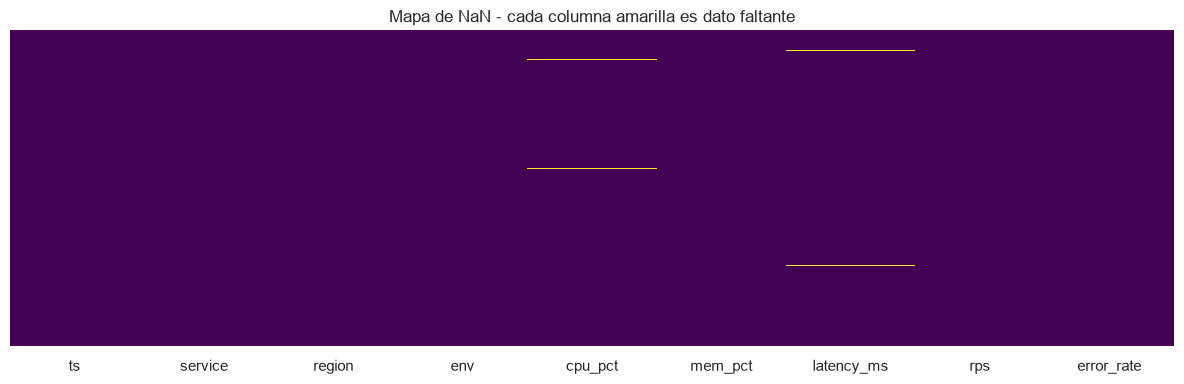

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(metrics.isnull(), cbar=False, yticklabels=False, cmap='viridis')
ax.set_title('Mapa de NaN - cada columna amarilla es dato faltante')
plt.tight_layout()
plt.savefig('../html/lab1_fig1_nan.png', dpi=110, bbox_inches='tight')
plt.show()

In [3]:
def clean_numeric(df, col, lo, hi):
    bad = (df[col] < lo) | (df[col] > hi)
    print(f'{col}: {bad.sum()} valores imposibles')
    df = df.loc[~bad].copy()
    df[col] = df[col].fillna(df[col].median())
    return df

metrics_clean = clean_numeric(metrics, 'latency_ms', 0, 10_000)
metrics_clean = clean_numeric(metrics_clean, 'cpu_pct', 0, 100)
print('shape limpio:', metrics_clean.shape)

latency_ms: 3869 valores imposibles


cpu_pct: 63511 valores imposibles


shape limpio: (904635, 9)


## 2. Personalidad de cada servicio - ¿consumen distinto?

**Que decidimos con este grafico:** que servicio tiene la media mas alta (candidato a compra de capacidad) y cual es estable (candidato a reducir).

**Cuando NO usar:** si los servicios tienen escalas radicalmente distintas, mejor normalizar a p95 o % de su propio baseline.

In [4]:
agg = metrics_clean.groupby('service').agg(
    cpu_mean=('cpu_pct', 'mean'),
    cpu_p95=('cpu_pct', lambda s: s.quantile(0.95)),
    mem_mean=('mem_pct', 'mean'),
    lat_p95=('latency_ms', lambda s: s.quantile(0.95)),
    err_mean=('error_rate', 'mean'),
).round(2)
agg['cpu_headroom'] = (100 - agg['cpu_p95']).round(1)
agg

,cpu_mean,cpu_p95,mem_mean,lat_p95,err_mean,cpu_headroom
service,,,,,,
auth-service,27.35,41.43,46.17,129.3,0.0,58.6
billing-worker,30.23,52.79,46.22,948.8,0.0,47.2
checkout-api,40.47,64.43,57.25,174.9,0.0,35.6
notifications,14.55,24.91,36.95,93.0,0.0,75.1
search-api,46.68,64.45,64.63,400.4,0.0,35.6


## 3. Decision visual - ¿quien necesita capacidad ya?

**Que decidimos:** si el headroom (margen hasta 100%) es bajo y la latencia p95 es alta, hay que comprar capacidad. Si todo es bajo, podemos bajar el tier.

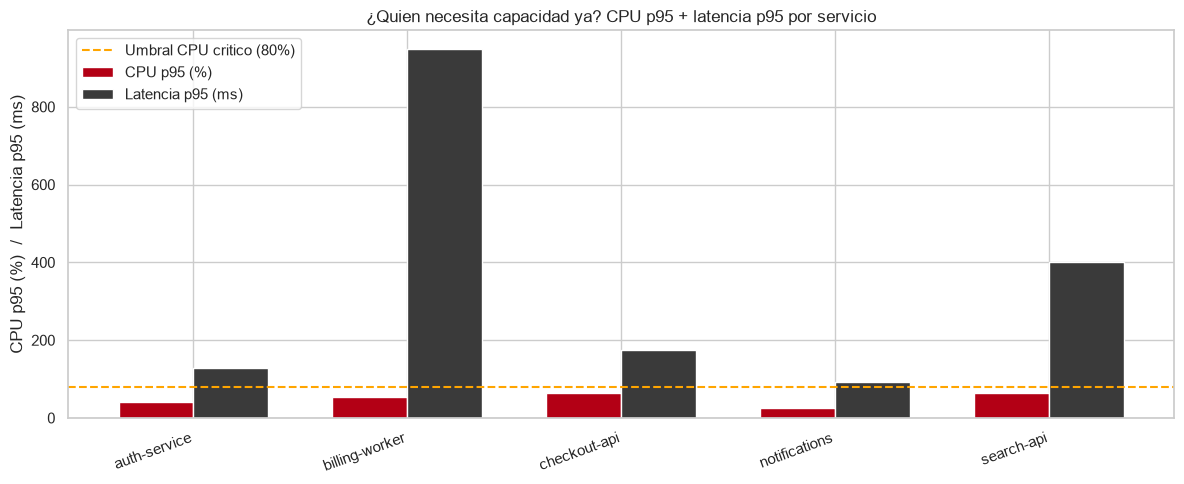

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
services = agg.index.tolist()
x = np.arange(len(services))
width = 0.35
ax.bar(x - width/2, agg['cpu_p95'], width, label='CPU p95 (%)', color='#b30015')
ax.bar(x + width/2, agg['lat_p95'], width, label='Latencia p95 (ms)', color='#3a3a3a')
ax.axhline(y=80, color='orange', linestyle='--', label='Umbral CPU critico (80%)')
ax.set_xticks(x)
ax.set_xticklabels(services, rotation=20, ha='right')
ax.set_ylabel('CPU p95 (%)  /  Latencia p95 (ms)')
ax.set_title('¿Quien necesita capacidad ya? CPU p95 + latencia p95 por servicio')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../html/lab1_fig2_capacity.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. Heatmap dia x hora x servicio - ¿cuando hay alertas?

**Que decidimos:** si hay un patron claro (ej: picos lunes 9-11am), podemos anticipar la capacidad con auto-scaling programado.

**Por que la escala es percentil 95:** porque la media esconde los picos. El p95 nos dice cual es el peor caso realista.

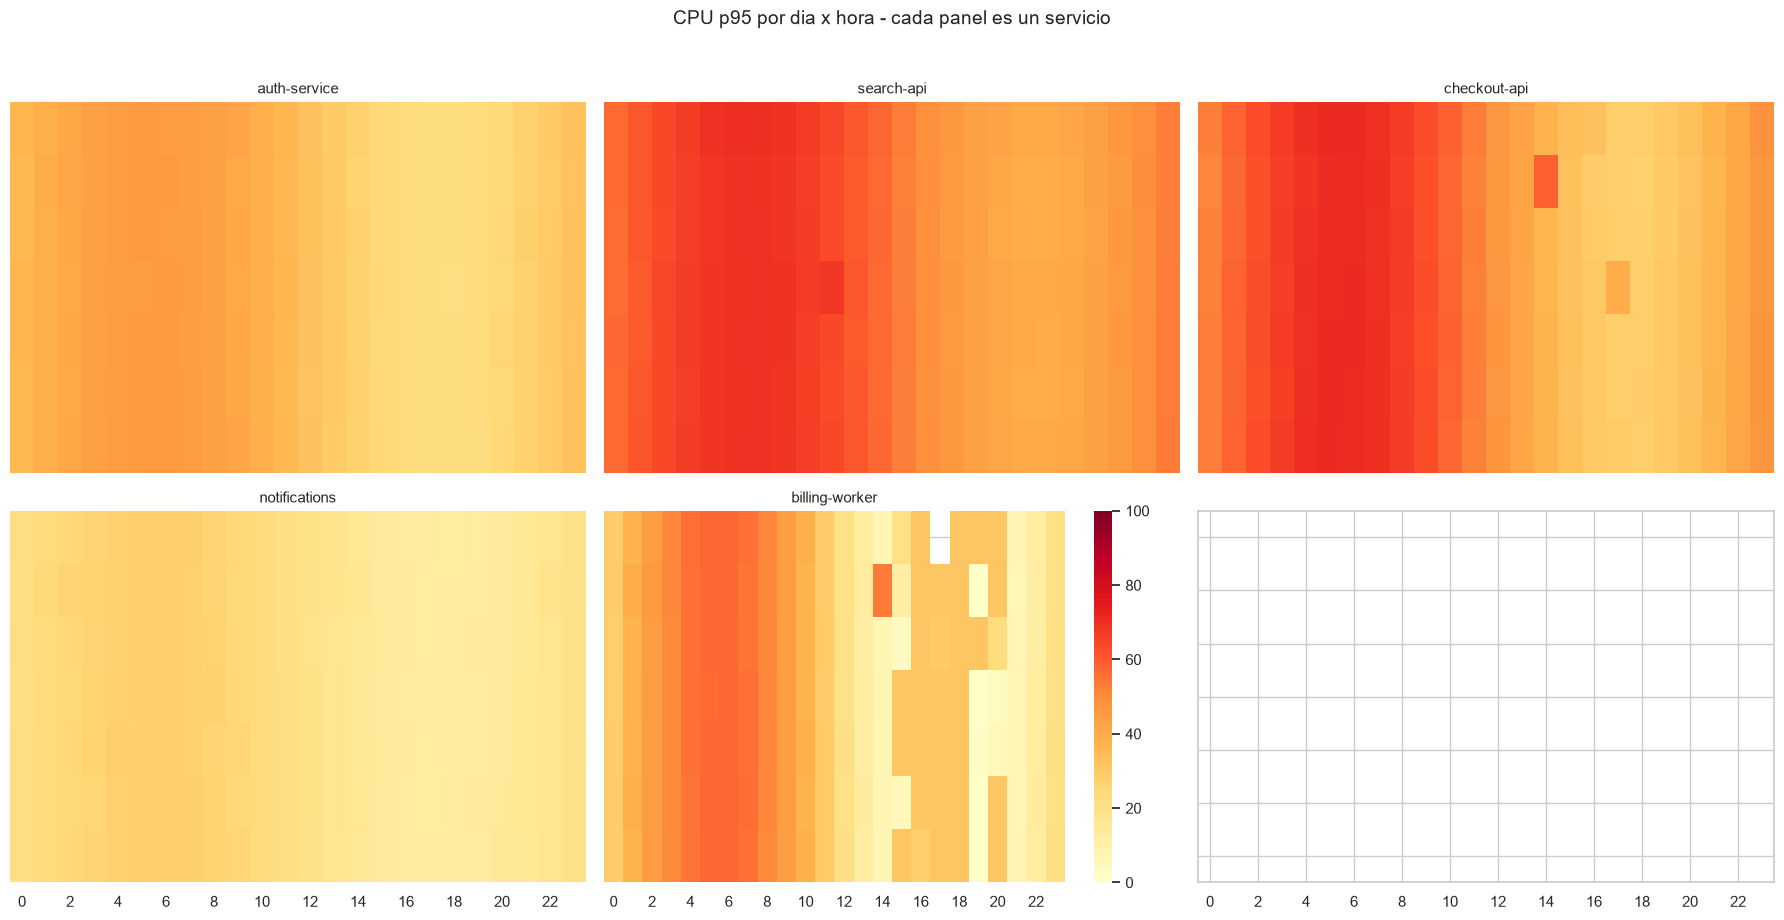

In [6]:
metrics_clean['dow'] = metrics_clean['ts'].dt.day_name()
metrics_clean['hour'] = metrics_clean['ts'].dt.hour
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
metrics_clean['dow'] = pd.Categorical(metrics_clean['dow'], categories=dow_order, ordered=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True, sharex=True)
services_sorted = metrics_clean['service'].value_counts().index.tolist()
for ax, svc in zip(axes.flatten(), services_sorted):
    sub = metrics_clean[metrics_clean['service'] == svc]
    pivot = sub.pivot_table(index='dow', columns='hour', values='cpu_pct', aggfunc=lambda s: s.quantile(0.95))
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', vmin=0, vmax=100, cbar=(svc == services_sorted[-1]))
    ax.set_title(svc, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    if svc != services_sorted[0]:
        ax.set_yticklabels([])
fig.suptitle('CPU p95 por dia x hora - cada panel es un servicio', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../html/lab1_fig3_heatmap_alerts.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Boxplot por servicio en escala log - los outliers reales

**Que decidimos:** el boxplot muestra la distribucion natural + outliers. Si los outliers son picos arriba del bigote = incidente. Si estan en ambos lados = bug del exporter.

**Por que escala log:** la mediana de purge_cache es 2 s y la de db_vacuum 120 s; sin log, los pequenos desaparecen.

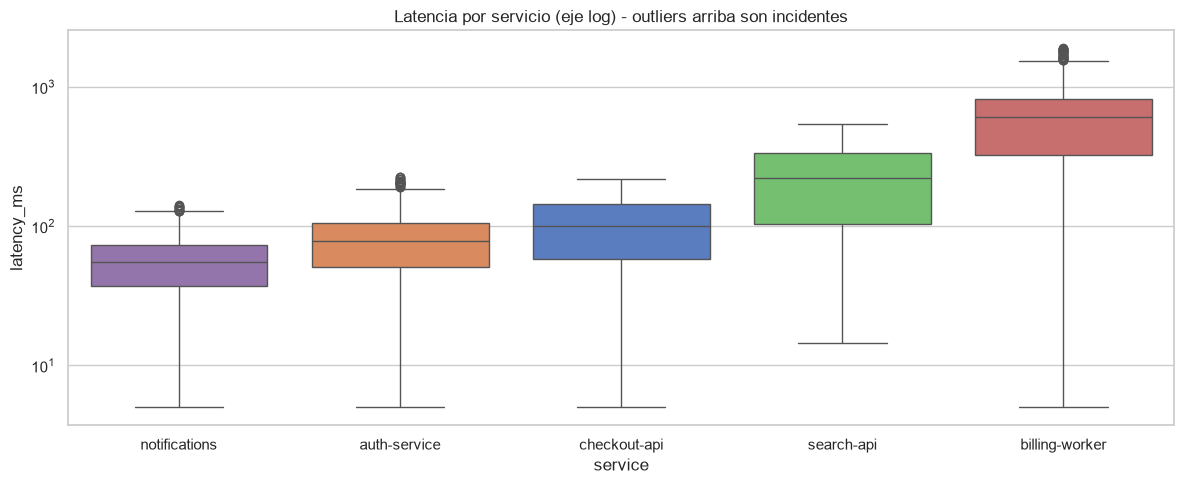

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
order = metrics_clean.groupby('service')['latency_ms'].median().sort_values().index
sns.boxplot(data=metrics_clean, x='service', y='latency_ms', order=order, hue='service', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Latencia por servicio (eje log) - outliers arriba son incidentes')
plt.tight_layout()
plt.savefig('../html/lab1_fig4_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Tu decision como SRE

Mirando los datos:
1. ¿Que servicio tiene el CPU p95 mas alto? (candidato a compra de capacidad)
2. ¿Que servicio muestra picos claros lunes-viernes 9-11am? (candidato a auto-scaling)
3. ¿Cual podrias bajar de tier por su consumo bajo estable?

**Argumenta con datos, no con intuicion.**